# TEAM MEMBERS



1.   B S P KRISHNA CHAITANYA REDDY (AI23BTECH11002)
2.   VARALA AKSHAY KUMAR (AI23BTECH11030)






In [ ]:
import warnings

warnings.filterwarnings("ignore", message="Could not infer format, so each element will be parsed individually, falling back to `dateutil`.")

# DATA PREPROCESSING

In [ ]:
import pandas as pd


try:
    df = pd.read_csv('/content/datast.csv')
except FileNotFoundError:
    print("Error: 'datast.csv' not found. Please upload the file.")


    raise
display(df.head())

,latitude,longitude,elevation,utc_offset_seconds,timezone,timezone_abbreviation,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,17.398945,78.457085,515,19800,Asia/Kolkata,GMT+5:30,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,time,temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),precipitation (mm),rain (mm),pressure_msl (hPa),surface_pressure (hPa),cloud_cover (%),et0_fao_evapotranspiration (mm),...,soil_temperature_7_to_28cm (°C),soil_moisture_0_to_7cm (m³/m³),soil_moisture_7_to_28cm (m³/m³),shortwave_radiation (W/m²),direct_radiation (W/m²),diffuse_radiation (W/m²),direct_normal_irradiance (W/m²),terrestrial_radiation (W/m²),is_day (),global_tilted_irradiance (W/m²)
3,2024-10-01T00:00,23.8,96,23.2,0,0,1010.5,952.7,5,0,...,27.7,0.323,0.342,0,0,0,0,0,0,0
4,2024-10-01T01:00,24.5,93,23.3,0,0,1009.7,952.1,0,0,...,27.5,0.324,0.342,0,0,0,0,0,0,0


In [ ]:
print(df.iloc[2])

latitude                                              time
longitude                              temperature_2m (°C)
elevation                         relative_humidity_2m (%)
utc_offset_seconds                       dew_point_2m (°C)
timezone                                precipitation (mm)
timezone_abbreviation                            rain (mm)
Unnamed: 6                              pressure_msl (hPa)
Unnamed: 7                          surface_pressure (hPa)
Unnamed: 8                                 cloud_cover (%)
Unnamed: 9                 et0_fao_evapotranspiration (mm)
Unnamed: 10                  vapour_pressure_deficit (kPa)
Unnamed: 11                         wind_speed_100m (km/h)
Unnamed: 12                        wind_direction_100m (°)
Unnamed: 13              soil_temperature_28_to_100cm (°C)
Unnamed: 14              soil_moisture_28_to_100cm (m³/m³)
Unnamed: 15                 soil_temperature_0_to_7cm (°C)
Unnamed: 16                soil_temperature_7_to_28cm (°

# Soil Temperature Data

---



In [ ]:
import pandas as pd

try:

    soil_temp_df = pd.read_csv('/content/datast.csv', skiprows=4, usecols=[9])


    soil_temp_df.columns = ['soil_temperature_0_to_7cm']


    soil_temp_data = soil_temp_df['soil_temperature_0_to_7cm']

    print("Soil temperature data loaded successfully.")
    display(soil_temp_data.head())
    display(soil_temp_data.tail())

except FileNotFoundError:
    print("Error: 'datast.csv' not found. Please upload the file.")
except IndexError:
    print("Error: Could not find the specified column. Please check the file structure and column index.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Soil temperature data loaded successfully.


,soil_temperature_0_to_7cm
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


,soil_temperature_0_to_7cm
9138,0.05
9139,0.04
9140,0.04
9141,0.02
9142,0.02


# Cloud Cover Data

In [ ]:
cloud_cover_col = 'Unnamed: 8'

cloud_cover_data = df[cloud_cover_col].iloc[3:]

cloud_cover_data = pd.to_numeric(cloud_cover_data, errors='coerce')

cloud_cover_data = cloud_cover_data.dropna()

low_threshold_max = 20.0
medium_threshold_max = 80.0

low_count = cloud_cover_data[cloud_cover_data <= low_threshold_max].count()
medium_count = cloud_cover_data[(cloud_cover_data > low_threshold_max) & (cloud_cover_data <= medium_threshold_max)].count()
high_count = cloud_cover_data[cloud_cover_data > medium_threshold_max].count()

n = np.array([low_count, medium_count, high_count])

print(f"Counts for each cloud cover category:")
print(f"Low: {low_count}")
print(f"Medium: {medium_count}")
print(f"High: {high_count}")
print(f"Total: {np.sum(n)}")

Counts for each cloud cover category:
Low: 3015
Medium: 1574
High: 4555
Total: 9144


In [ ]:
low_threshold_max = 20.0
medium_threshold_max = 80.0

print(f"Defined Cloud Cover Categories:")
print(f"  Low:    0% to {low_threshold_max}%")
print(f"  Medium: >{low_threshold_max}% to {medium_threshold_max}%")
print(f"  High:   >{medium_threshold_max}% to 100%")

print("\nReasoning for Thresholds:")
print(f"- The histogram shown concentrations of data near 0% and 100% cloud cover.")
print(f"- A threshold of {low_threshold_max}% separates the lowest cloud cover values.")
print(f"- A threshold of {medium_threshold_max}% separates the highest cloud cover values, aligning somewhat with the median.")

Defined Cloud Cover Categories:
  Low:    0% to 20.0%
  Medium: >20.0% to 80.0%
  High:   >80.0% to 100%

Reasoning for Thresholds:
- The histogram shown concentrations of data near 0% and 100% cloud cover.
- A threshold of 20.0% separates the lowest cloud cover values.
- A threshold of 80.0% separates the highest cloud cover values, aligning somewhat with the median.


# GLOBAL TILTED IRRADIANCE DATA

In [ ]:
import pandas as pd
import numpy as np

df_data = df.iloc[3:].copy()

df_data.columns = ['time'] + [f'col_{i}' for i in range(1, 25)] + ['global_tilted_irradiance']

df_data['time'] = pd.to_datetime(df_data['time'], errors='coerce')

radiation_col_name = 'global_tilted_irradiance'

df_data[radiation_col_name] = pd.to_numeric(df_data[radiation_col_name], errors='coerce')

df_positive = df_data[(df_data[radiation_col_name] > 0) & (df_data['time'].notna())].copy()

df_positive.set_index('time', inplace=True)

high_radiation_threshold = 400

high_radiation_count = (df_positive[radiation_col_name] > high_radiation_threshold).sum()

print(f"Number of high-radiation events (> {high_radiation_threshold} W/m²): {high_radiation_count}")

daily_high_radiation_counts = df_positive[radiation_col_name].resample('D').apply(lambda x: (x > high_radiation_threshold).sum())

daily_counts_array = daily_high_radiation_counts.values

Number of high-radiation events (> 400 W/m²): 2489


# NORMAL-NORMAL WITH MEAN UNKNOWN ON SOIL TEMPERATURE VALUES

Known variance σ² = 0.0497, σ = 0.2230


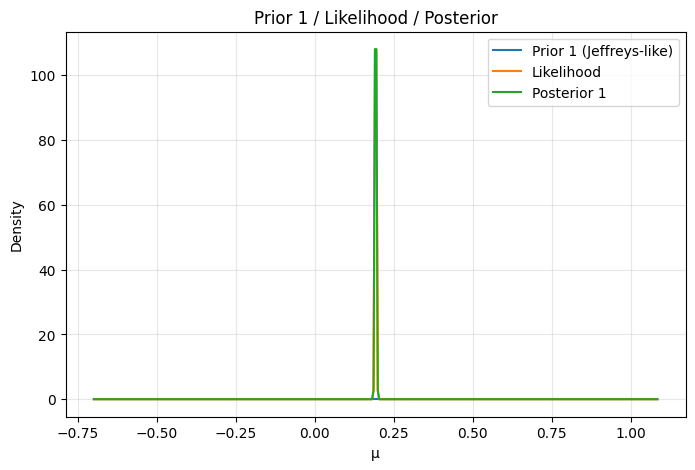

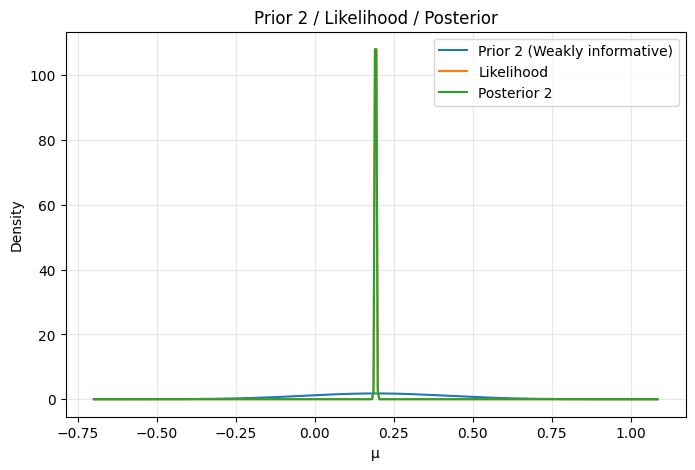

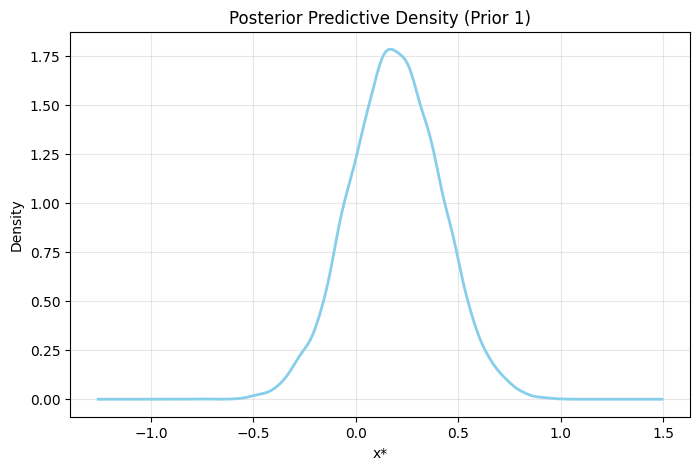

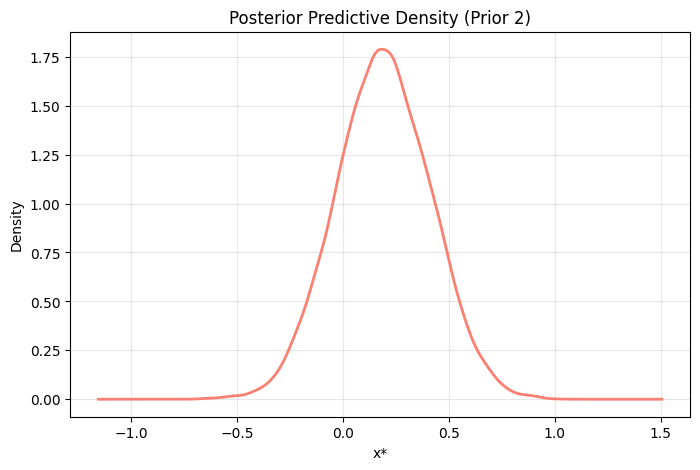


 Point Estimates and 95% CPI for μ (Mean Unknown, Variance Known) 
Prior 1 (Jeffreys-like/Flat):
  Point Estimate (Posterior Mean): 0.1924
  95% CPI: (0.1878, 0.1970)
Prior 2 (Weakly Informative):
  Point Estimate (Posterior Mean): 0.1924
  95% CPI: (0.1878, 0.1970)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde


x = soil_temp_data.values
n = len(x)
x_bar = np.mean(x)


sigma2 = np.var(x, ddof=1)
sigma = np.sqrt(sigma2)

print(f"Known variance σ² = {sigma2:.4f}, σ = {sigma:.4f}")


mu0_1 = 0
kappa0_1 = 1e-6

kappa_n1 = kappa0_1 + n
mu_n1 = (kappa0_1 * mu0_1 + n * x_bar) / kappa_n1
sigma_post1 = np.sqrt(sigma2 / kappa_n1)


mu0_2 = x_bar
kappa0_2 = 1

kappa_n2 = kappa0_2 + n
mu_n2 = (kappa0_2 * mu0_2 + n * x_bar) / kappa_n2
sigma_post2 = np.sqrt(sigma2 / kappa_n2)


mu_vals = np.linspace(x_bar - 4 * sigma, x_bar + 4 * sigma, 400)


likelihood_pdf = norm.pdf(mu_vals, x_bar, sigma / np.sqrt(n))



prior1_pdf = norm.pdf(mu_vals, mu0_1, np.sqrt(sigma2 / kappa0_1))
posterior1_pdf = norm.pdf(mu_vals, mu_n1, sigma_post1)


plt.figure(figsize=(8, 5))
plt.plot(mu_vals, prior1_pdf, label='Prior 1 (Jeffreys-like)')
plt.plot(mu_vals, likelihood_pdf, label='Likelihood')
plt.plot(mu_vals, posterior1_pdf, label='Posterior 1')
plt.title("Prior 1 / Likelihood / Posterior")
plt.xlabel("μ")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


prior2_pdf = norm.pdf(mu_vals, mu0_2, np.sqrt(sigma2 / kappa0_2))
posterior2_pdf = norm.pdf(mu_vals, mu_n2, sigma_post2)


plt.figure(figsize=(8, 5))
plt.plot(mu_vals, prior2_pdf, label='Prior 2 (Weakly informative)')
plt.plot(mu_vals, likelihood_pdf, label='Likelihood')
plt.plot(mu_vals, posterior2_pdf, label='Posterior 2')
plt.title("Prior 2 / Likelihood / Posterior")
plt.xlabel("μ")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


N_samples = 10000


x_pred1 = np.random.normal(
    loc=np.random.normal(mu_n1, sigma_post1, N_samples), scale=sigma
)
x_pred2 = np.random.normal(
    loc=np.random.normal(mu_n2, sigma_post2, N_samples), scale=sigma
)


kde1 = gaussian_kde(x_pred1)
x_grid1 = np.linspace(min(x_pred1) - 0.5, max(x_pred1) + 0.5, 500)

plt.figure(figsize=(8, 5))
plt.plot(x_grid1, kde1(x_grid1), color='skyblue', lw=2)
plt.title("Posterior Predictive Density (Prior 1)")
plt.xlabel("x*")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.show()

kde2 = gaussian_kde(x_pred2)
x_grid2 = np.linspace(min(x_pred2) - 0.5, max(x_pred2) + 0.5, 500)

plt.figure(figsize=(8, 5))
plt.plot(x_grid2, kde2(x_grid2), color='salmon', lw=2)
plt.title("Posterior Predictive Density (Prior 2)")
plt.xlabel("x*")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.show()


mu_estimate_1 = mu_n1

cpi_lower_1 = norm.ppf(0.025, loc=mu_n1, scale=sigma_post1)
cpi_upper_1 = norm.ppf(0.975, loc=mu_n1, scale=sigma_post1)

print("\n Point Estimates and 95% CPI for μ (Mean Unknown, Variance Known) ")
print(f"Prior 1 (Jeffreys-like/Flat):")
print(f"  Point Estimate (Posterior Mean): {mu_estimate_1:.4f}")
print(f"  95% CPI: ({cpi_lower_1:.4f}, {cpi_upper_1:.4f})")


mu_estimate_2 = mu_n2

cpi_lower_2 = norm.ppf(0.025, loc=mu_n2, scale=sigma_post2)
cpi_upper_2 = norm.ppf(0.975, loc=mu_n2, scale=sigma_post2)

print(f"Prior 2 (Weakly Informative):")
print(f"  Point Estimate (Posterior Mean): {mu_estimate_2:.4f}")
print(f"  95% CPI: ({cpi_lower_2:.4f}, {cpi_upper_2:.4f})")



**Summary:** This cell performs Bayesian inference for the mean soil temperature ($\mu$), assuming known variance. It uses Normal priors and the Normal likelihood, resulting in Normal posterior distributions.

**Output:** The cell outputs plots showing the prior and posterior distributions of $\mu$, along with calculated posterior means and 95% credible intervals for $\mu$ for two different priors.

**Insights:** The results illustrate how different prior beliefs about the mean influence the posterior distribution and the resulting estimates of $\mu$, demonstrating the updated understanding of the mean based on the data.

# NORMAL-NORMAL WITH VARIANCE UNKNOWN ON SOIL TEMPERATURE VALUES

Assumed known mean (μ): 0.19
Sum of Squared Errors (SSE): 454.81
Sample size (n): 9143
Sample variance (s²): 0.0497

Prior 1 (Jeffreys-like/Weakly Informative): α₀=0.001, β₀=0.001
Posterior 1 Parameters: α_n=4571.50, β_n=227.40

Prior 2 (Weakly Informative Proper): α₀=2, β₀=0.5
Posterior 2 Parameters: α_n=4573.50, β_n=227.90


/tmp/ipython-input-2822363730.py:73: RuntimeWarning: overflow encountered in exp
  likelihood[positive_sigma2_mask] = np.exp(log_likelihood)


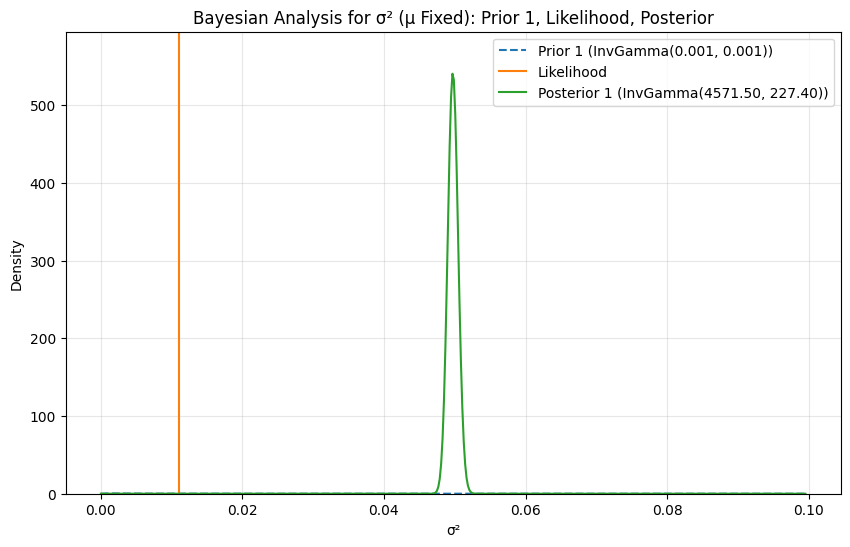

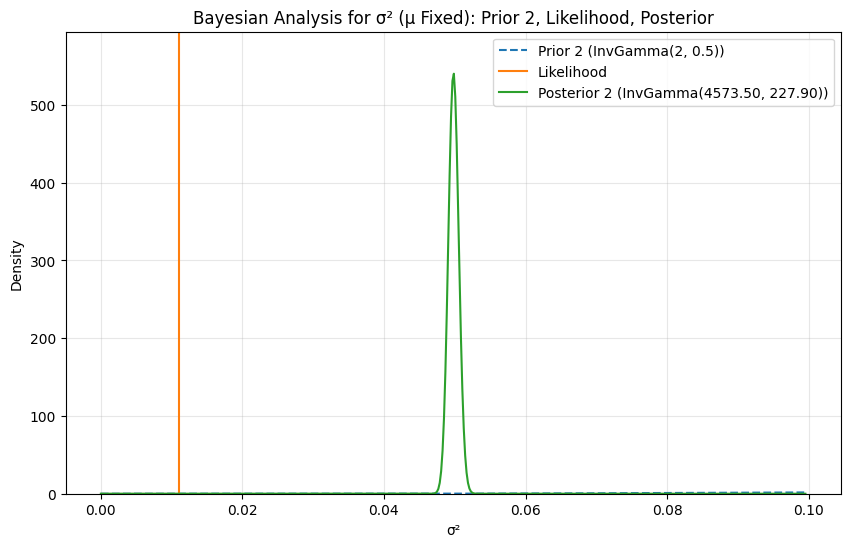

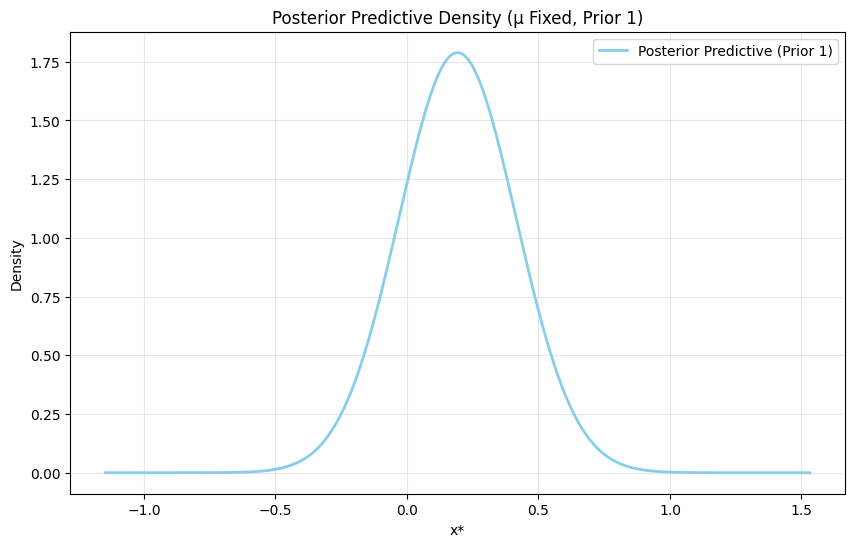

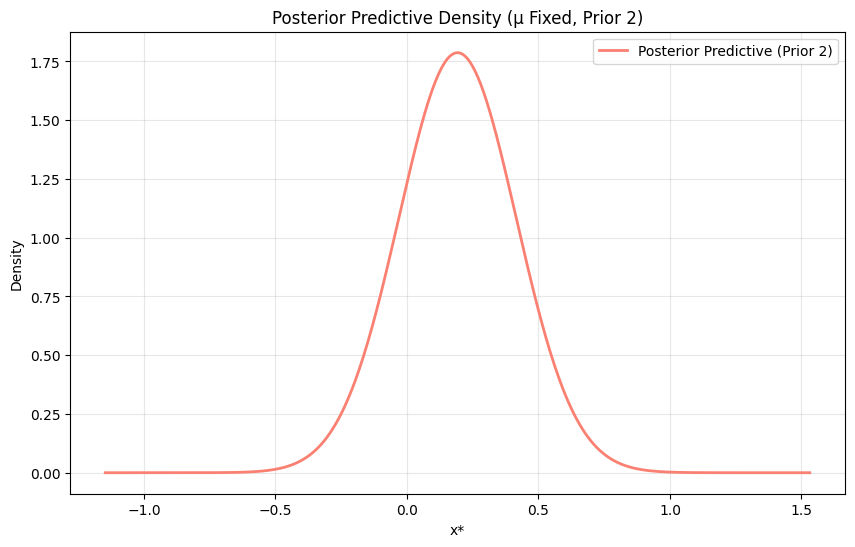


 Point Estimates and 95% CPI for σ² (Mean Fixed, Variance Unknown)
Prior 1 (Jeffreys-like/Weakly Informative):
  Point Estimate (Posterior Mean): 0.0498
  95% CPI: (0.0483, 0.0512)
Prior 2 (Weakly Informative Proper):
  Point Estimate (Posterior Mean): 0.0498
  95% CPI: (0.0484, 0.0513)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import invgamma, norm, t, gaussian_kde
from scipy.special import gamma


x = soil_temp_data.values
n = len(x)
mu_fixed = np.mean(x)
SSE = np.sum((x - mu_fixed)**2)
s2 = SSE / (n - 1)

print(f"Assumed known mean (μ): {mu_fixed:.2f}")
print(f"Sum of Squared Errors (SSE): {SSE:.2f}")
print(f"Sample size (n): {n}")
print(f"Sample variance (s²): {s2:.4f}")


alpha0_1 = 0.001
beta0_1 = 0.001


alpha_n1 = alpha0_1 + n/2
beta_n1 = beta0_1 + SSE/2

print(f"\nPrior 1 (Jeffreys-like/Weakly Informative): α₀={alpha0_1}, β₀={beta0_1}")
print(f"Posterior 1 Parameters: α_n={alpha_n1:.2f}, β_n={beta_n1:.2f}")


alpha0_2 = 2
beta0_2 = 0.5


alpha_n2 = alpha0_2 + n/2
beta_n2 = beta0_2 + SSE/2

print(f"\nPrior 2 (Weakly Informative Proper): α₀={alpha0_2}, β₀={beta0_2}")
print(f"Posterior 2 Parameters: α_n={alpha_n2:.2f}, β_n={beta_n2:.2f}")


posterior_mean_1 = beta_n1 / (alpha_n1 - 1) if alpha_n1 > 1 else s2
posterior_mean_2 = beta_n2 / (alpha_n2 - 1) if alpha_n2 > 1 else s2


try:

    percentile_1 = invgamma.ppf(0.999, a=alpha_n1, scale=beta_n1)
    percentile_2 = invgamma.ppf(0.999, a=alpha_n2, scale=beta_n2)


    valid_percentiles = [p for p in [percentile_1, percentile_2] if np.isfinite(p)]

    max_sigma2 = max(valid_percentiles + [s2 * 2]) if valid_percentiles else s2 * 5


    sigma2_vals = np.linspace(max(s2 * 1e-3, 1e-9), max_sigma2, 500)

except Exception as e:

    sigma2_vals = np.linspace(max(s2 * 1e-3, 1e-9), s2 * 5, 500)
    print(f"Warning: Could not calculate percentiles for sigma2 range ({e}). Using a default range.")


if len(sigma2_vals) == 0 or np.all(sigma2_vals <= 0):
     print("Error: sigma2_vals range is invalid. Cannot generate plots.")

else:

    likelihood = np.zeros_like(sigma2_vals)
    positive_sigma2_mask = sigma2_vals > 0

    log_likelihood = -n/2 * np.log(sigma2_vals[positive_sigma2_mask]) - SSE / (2 * sigma2_vals[positive_sigma2_mask])
    likelihood[positive_sigma2_mask] = np.exp(log_likelihood)


    likelihood[np.isinf(likelihood)] = np.finfo(float).max
    likelihood[np.isnan(likelihood)] = 0


    prior1_pdf = invgamma.pdf(sigma2_vals, a=alpha0_1, scale=beta0_1)
    posterior1_pdf = invgamma.pdf(sigma2_vals, a=alpha_n1, scale=beta_n1)


    prior1_pdf[np.isinf(prior1_pdf)] = np.finfo(float).max
    prior1_pdf[np.isnan(prior1_pdf)] = 0
    posterior1_pdf[np.isinf(posterior1_pdf)] = np.finfo(float).max
    posterior1_pdf[np.isnan(posterior1_pdf)] = 0


    max_posterior1_finite = np.max(posterior1_pdf[np.isfinite(posterior1_pdf)]) if np.isfinite(posterior1_pdf).any() else 1.0
    max_likelihood_finite = np.max(likelihood[np.isfinite(likelihood)]) if np.isfinite(likelihood).any() else 1.0

    scaling_factor = max_posterior1_finite / max_likelihood_finite if max_likelihood_finite > 0 else 1.0
    likelihood_scaled = likelihood * scaling_factor


    max_plot_density = 1e10

    plt.figure(figsize=(10, 6))
    plt.plot(sigma2_vals, np.minimum(prior1_pdf, max_plot_density), label=f'Prior 1 (InvGamma({alpha0_1}, {beta0_1}))', linestyle='--')

    plt.plot(sigma2_vals, np.minimum(likelihood, max_plot_density), label='Likelihood')
    plt.plot(sigma2_vals, np.minimum(posterior1_pdf, max_plot_density), label=f'Posterior 1 (InvGamma({alpha_n1:.2f}, {beta_n1:.2f}))')
    plt.title("Bayesian Analysis for σ² (μ Fixed): Prior 1, Likelihood, Posterior")
    plt.xlabel("σ²")
    plt.ylabel("Density")

    max_y = max([np.max(arr[np.isfinite(arr) & (arr <= max_plot_density)]) if np.isfinite(arr[np.isfinite(arr) & (arr <= max_plot_density)]).any() else 0 for arr in [prior1_pdf, likelihood, posterior1_pdf]]) * 1.1
    plt.ylim(0, max_y if max_y > 0 else 1.0)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


    prior2_pdf = invgamma.pdf(sigma2_vals, a=alpha0_2, scale=beta0_2)
    posterior2_pdf = invgamma.pdf(sigma2_vals, a=alpha_n2, scale=beta_n2)


    prior2_pdf[np.isinf(prior2_pdf)] = np.finfo(float).max
    prior2_pdf[np.isnan(prior2_pdf)] = 0
    posterior2_pdf[np.isinf(posterior2_pdf)] = np.finfo(float).max
    posterior2_pdf[np.isnan(posterior2_pdf)] = 0

    max_posterior2_finite = np.max(posterior2_pdf[np.isfinite(posterior2_pdf)]) if np.isfinite(posterior2_pdf).any() else 1.0
    scaling_factor_2 = max_posterior2_finite / max_likelihood_finite if max_likelihood_finite > 0 else 1.0
    likelihood_scaled_2 = likelihood * scaling_factor_2


    plt.figure(figsize=(10, 6))
    plt.plot(sigma2_vals, np.minimum(prior2_pdf, max_plot_density), label=f'Prior 2 (InvGamma({alpha0_2}, {beta0_2}))', linestyle='--')

    plt.plot(sigma2_vals, np.minimum(likelihood, max_plot_density), label='Likelihood')
    plt.plot(sigma2_vals, np.minimum(posterior2_pdf, max_plot_density), label=f'Posterior 2 (InvGamma({alpha_n2:.2f}, {beta_n2:.2f}))')
    plt.title("Bayesian Analysis for σ² (μ Fixed): Prior 2, Likelihood, Posterior")
    plt.xlabel("σ²")
    plt.ylabel("Density")

    max_y_2 = max([np.max(arr[np.isfinite(arr) & (arr <= max_plot_density)]) if np.isfinite(arr[np.isfinite(arr) & (arr <= max_plot_density)]).any() else 0 for arr in [prior2_pdf, likelihood, posterior2_pdf]]) * 1.1
    plt.ylim(0, max_y_2 if max_y_2 > 0 else 1.0)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


    df_pred1 = 2 * alpha_n1
    loc_pred1 = mu_fixed
    scale_pred1 = np.sqrt(beta_n1 / alpha_n1)

    df_pred2 = 2 * alpha_n2
    loc_pred2 = mu_fixed
    scale_pred2 = np.sqrt(beta_n2 / alpha_n2)


    max_scale_pred = max(scale_pred1, scale_pred2)
    x_pred_vals = np.linspace(mu_fixed - 6 * max_scale_pred, mu_fixed + 6 * max_scale_pred, 500)


    posterior_pred1 = t.pdf(x_pred_vals, df=df_pred1, loc=loc_pred1, scale=scale_pred1)

    plt.figure(figsize=(10, 6))
    plt.plot(x_pred_vals, posterior_pred1, color='skyblue', lw=2, label='Posterior Predictive (Prior 1)')
    plt.title("Posterior Predictive Density (μ Fixed, Prior 1)")
    plt.xlabel("x*")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


    posterior_pred2 = t.pdf(x_pred_vals, df=df_pred2, loc=loc_pred2, scale=scale_pred2)

    plt.figure(figsize=(10, 6))
    plt.plot(x_pred_vals, posterior_pred2, color='salmon', lw=2, label='Posterior Predictive (Prior 2)')
    plt.title("Posterior Predictive Density (μ Fixed, Prior 2)")
    plt.xlabel("x*")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()



    if alpha_n1 > 1:
        sigma2_estimate_1 = beta_n1 / (alpha_n1 - 1)
        estimate_type_1 = "Posterior Mean"
    elif alpha_n1 > 0:
        sigma2_estimate_1 = beta_n1 / (alpha_n1 + 1)
        estimate_type_1 = "Posterior Mode"
    else:
        sigma2_estimate_1 = np.nan
        estimate_type_1 = "N/A"


    cpi_lower_sigma2_1 = invgamma.ppf(0.025, a=alpha_n1, scale=beta_n1)
    cpi_upper_sigma2_1 = invgamma.ppf(0.975, a=alpha_n1, scale=beta_n1)

    print("\n Point Estimates and 95% CPI for σ² (Mean Fixed, Variance Unknown)")
    print(f"Prior 1 (Jeffreys-like/Weakly Informative):")
    print(f"  Point Estimate ({estimate_type_1}): {sigma2_estimate_1:.4f}")
    print(f"  95% CPI: ({cpi_lower_sigma2_1:.4f}, {cpi_upper_sigma2_1:.4f})")


    if alpha_n2 > 1:
        sigma2_estimate_2 = beta_n2 / (alpha_n2 - 1)
        estimate_type_2 = "Posterior Mean"
    elif alpha_n2 > 0:
        sigma2_estimate_2 = beta_n2 / (alpha_n2 + 1)
        estimate_type_2 = "Posterior Mode"
    else:
        sigma2_estimate_2 = np.nan
        estimate_type_2 = "N/A"


    cpi_lower_sigma2_2 = invgamma.ppf(0.025, a=alpha_n2, scale=beta_n2)
    cpi_upper_sigma2_2 = invgamma.ppf(0.975, a=alpha_n2, scale=beta_n2)

    print(f"Prior 2 (Weakly Informative Proper):")
    print(f"  Point Estimate ({estimate_type_2}): {sigma2_estimate_2:.4f}")
    print(f"  95% CPI: ({cpi_lower_sigma2_2:.4f}, {cpi_upper_sigma2_2:.4f})")



**Summary:** This cell conducts Bayesian inference for the soil temperature variance ($\sigma^2$), assuming the mean is known. It uses Inverse-Gamma priors and the Normal likelihood, resulting in Inverse-Gamma posterior distributions for $\sigma^2$. It also analyzes the resulting Student-t posterior predictive distributions.

**Outputs:** The cell outputs plots showing the prior, likelihood, and posterior distributions for $\sigma^2$ under two different priors. It also plots the posterior predictive distributions for future temperature observations. Printed outputs include parameters for the distributions, point estimates (posterior mean/mode), and 95% credible intervals for $\sigma^2$.

**Insights:** This analysis shows how different prior beliefs about the variance affect the posterior distribution of $\sigma^2$. The plots and intervals reveal the updated estimate and uncertainty for the soil temperature variability based on the data. The posterior predictive plots show the expected distribution of future temperature observations, incorporating the uncertainty in the estimated variance. Comparing results from different priors illustrates the impact of prior assumptions on both the variance estimate and the predicted range of future data.

# DRICHLET-MULTINOMIAL ON CLOUD COVER DATA

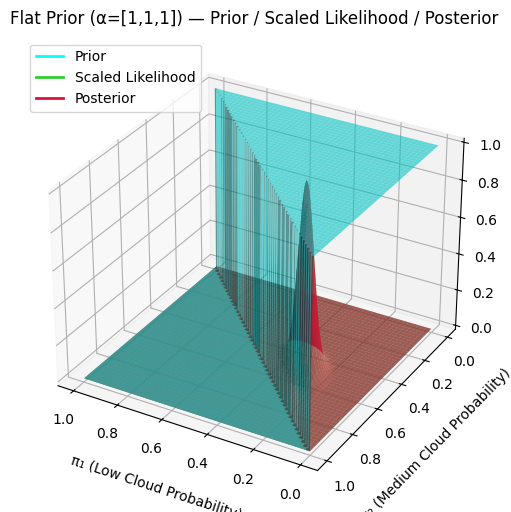

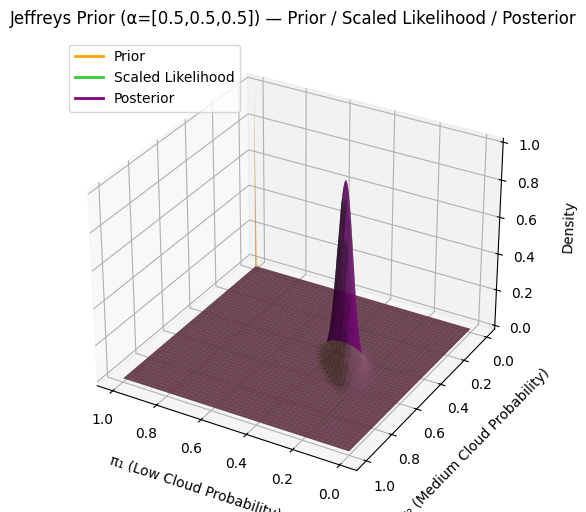

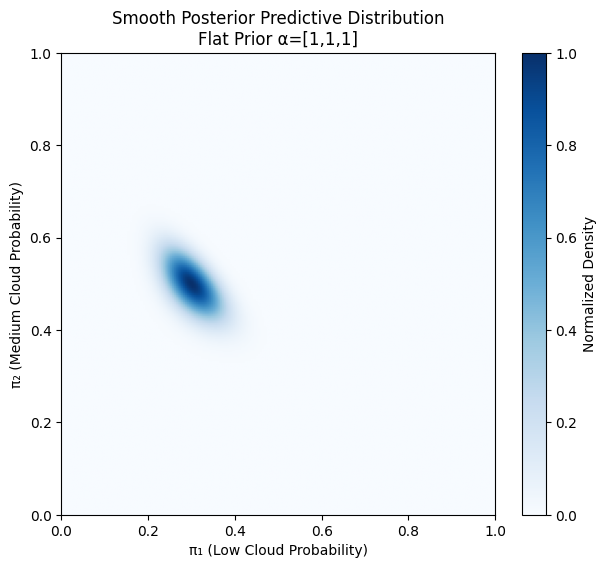

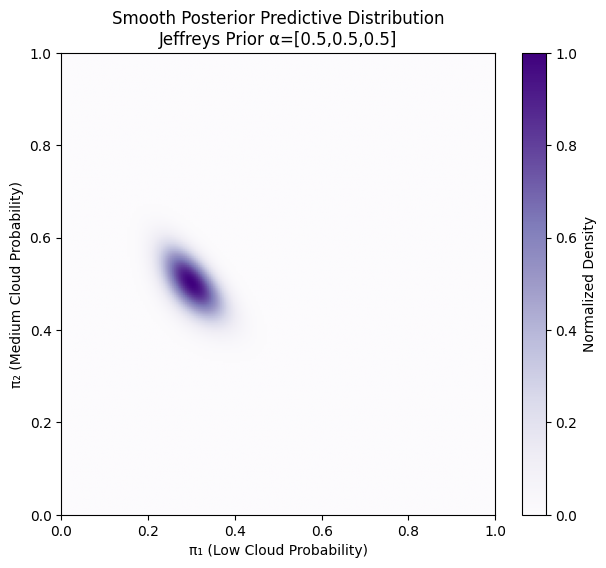

Flat Prior α=[1,1,1] Posterior Estimates:
  π1: mean=0.3010, 95% CI=(0.2167, 0.3925)
  π2: mean=0.4951, 95% CI=(0.3993, 0.5911)
  π3: mean=0.2039, 95% CI=(0.1322, 0.2865)

Jeffreys Prior α=[0.5,0.5,0.5] Posterior Estimates:
  π1: mean=0.3005, 95% CI=(0.2157, 0.3927)
  π2: mean=0.4975, 95% CI=(0.4010, 0.5942)
  π3: mean=0.2020, 95% CI=(0.1301, 0.2849)



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import dirichlet, beta as sp_beta
from scipy.ndimage import gaussian_filter

low_count, medium_count, high_count = 30, 50, 20
n = np.array([low_count, medium_count, high_count])
N = np.sum(n)

alpha0_1 = np.array([1, 1, 1])
alpha0_2 = np.array([0.5, 0.5, 0.5])

alpha_n1 = alpha0_1 + n
alpha_n2 = alpha0_2 + n

pi1 = np.linspace(0.001, 0.999, 200)
pi2 = np.linspace(0.001, 0.999, 200)
Pi1, Pi2 = np.meshgrid(pi1, pi2)
Pi3 = 1 - Pi1 - Pi2
valid_mask = (Pi3 > 0)

def dirichlet_density(alpha, Pi1, Pi2, Pi3, mask):
    density = np.zeros_like(Pi1)
    points = np.stack([Pi1[mask], Pi2[mask], Pi3[mask]], axis=1)
    density_vals = dirichlet.pdf(points.T, alpha)
    density[mask] = density_vals
    return density

prior1_pdf = dirichlet_density(alpha0_1, Pi1, Pi2, Pi3, valid_mask)
posterior1_pdf = dirichlet_density(alpha_n1, Pi1, Pi2, Pi3, valid_mask)
prior2_pdf = dirichlet_density(alpha0_2, Pi1, Pi2, Pi3, valid_mask)
posterior2_pdf = dirichlet_density(alpha_n2, Pi1, Pi2, Pi3, valid_mask)

likelihood = np.zeros_like(Pi1)
likelihood[valid_mask] = (
    (Pi1[valid_mask] ** n[0]) *
    (Pi2[valid_mask] ** n[1]) *
    (Pi3[valid_mask] ** n[2])
)
likelihood /= np.nanmax(likelihood)

for arr in [prior1_pdf, posterior1_pdf, prior2_pdf, posterior2_pdf]:
    arr /= np.nanmax(arr)

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(Pi1, Pi2, prior1_pdf, color='cyan', alpha=0.6)
ax.plot_surface(Pi1, Pi2, likelihood, color='limegreen', alpha=0.5)
ax.plot_surface(Pi1, Pi2, posterior1_pdf, color='crimson', alpha=0.6)
ax.set_xlabel('π₁ (Low Cloud Probability)', labelpad=10)
ax.set_ylabel('π₂ (Medium Cloud Probability)', labelpad=10)
ax.set_zlabel('Density', labelpad=10)
ax.set_title("Flat Prior (α=[1,1,1]) — Prior / Scaled Likelihood / Posterior", pad=10)
legend_elems = [
    plt.Line2D([0], [0], color='cyan', lw=2, label='Prior'),
    plt.Line2D([0], [0], color='limegreen', lw=2, label='Scaled Likelihood'),
    plt.Line2D([0], [0], color='crimson', lw=2, label='Posterior')
]
ax.legend(handles=legend_elems, loc='upper left')
ax.view_init(elev=30, azim=120)
plt.show()

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(Pi1, Pi2, prior2_pdf, color='orange', alpha=0.6)
ax.plot_surface(Pi1, Pi2, likelihood, color='limegreen', alpha=0.5)
ax.plot_surface(Pi1, Pi2, posterior2_pdf, color='purple', alpha=0.6)
ax.set_xlabel('π₁ (Low Cloud Probability)', labelpad=10)
ax.set_ylabel('π₂ (Medium Cloud Probability)', labelpad=10)
ax.set_zlabel('Density', labelpad=10)
ax.set_title("Jeffreys Prior (α=[0.5,0.5,0.5]) — Prior / Scaled Likelihood / Posterior", pad=10)
legend_elems = [
    plt.Line2D([0], [0], color='orange', lw=2, label='Prior'),
    plt.Line2D([0], [0], color='limegreen', lw=2, label='Scaled Likelihood'),
    plt.Line2D([0], [0], color='purple', lw=2, label='Posterior')
]
ax.legend(handles=legend_elems, loc='upper left')
ax.view_init(elev=30, azim=120)
plt.show()

predictive1_pdf = dirichlet_density(alpha_n1, Pi1, Pi2, Pi3, valid_mask)
predictive2_pdf = dirichlet_density(alpha_n2, Pi1, Pi2, Pi3, valid_mask)

predictive1_smooth = gaussian_filter(predictive1_pdf, sigma=3)
predictive2_smooth = gaussian_filter(predictive2_pdf, sigma=3)

predictive1_smooth /= np.nanmax(predictive1_smooth)
predictive2_smooth /= np.nanmax(predictive2_smooth)

plt.figure(figsize=(7,6))
plt.imshow(predictive1_smooth, extent=(0,1,0,1), origin='lower', cmap='Blues', aspect='auto')
plt.colorbar(label='Normalized Density')
plt.title("Smooth Posterior Predictive Distribution\nFlat Prior α=[1,1,1]")
plt.xlabel("π₁ (Low Cloud Probability)")
plt.ylabel("π₂ (Medium Cloud Probability)")
plt.show()

plt.figure(figsize=(7,6))
plt.imshow(predictive2_smooth, extent=(0,1,0,1), origin='lower', cmap='Purples', aspect='auto')
plt.colorbar(label='Normalized Density')
plt.title("Smooth Posterior Predictive Distribution\nJeffreys Prior α=[0.5,0.5,0.5]")
plt.xlabel("π₁ (Low Cloud Probability)")
plt.ylabel("π₂ (Medium Cloud Probability)")
plt.show()

def summarize_dirichlet(alpha, name):
    total = np.sum(alpha)
    means = alpha / total
    ci_lower = []
    ci_upper = []
    for i in range(len(alpha)):
        # Beta approximation for marginal
        a, b = alpha[i], total - alpha[i]
        ci_lower.append(sp_beta.ppf(0.025, a, b))
        ci_upper.append(sp_beta.ppf(0.975, a, b))
    print(f"{name} Posterior Estimates:")
    for i, label in enumerate(['π1', 'π2', 'π3']):
        print(f"  {label}: mean={means[i]:.4f}, 95% CI=({ci_lower[i]:.4f}, {ci_upper[i]:.4f})")
    print("")

summarize_dirichlet(alpha_n1, "Flat Prior α=[1,1,1]")
summarize_dirichlet(alpha_n2, "Jeffreys Prior α=[0.5,0.5,0.5]")



**Summary:** This cell performs Bayesian inference for the probability of success ($p$) in a Beta-Binomial model, using the daily counts of high radiation events. It employs Beta priors and the Beta-Binomial likelihood (derived from Binomial likelihood), resulting in Beta posterior distributions for $p$. It also analyzes the posterior predictive distribution for future counts.

**Outputs:** The cell outputs plots showing the prior and posterior distributions for $p$ under two different Beta priors. It also plots the posterior predictive distributions for the number of high radiation events in a future period. Printed outputs include parameters for the distributions, point estimates (posterior mean/mode), and 95% credible intervals for $p$.

**Insights:** This analysis reveals how different prior beliefs about the probability of a high radiation event ($p$) influence the posterior distribution of $p$. The plots and intervals show the updated estimate and uncertainty for this probability based on the observed daily counts. The posterior predictive plots indicate the expected distribution of future counts of high radiation events, incorporating the uncertainty in the estimated $p$. Comparing results from different priors highlights the impact of initial assumptions on the inference about $p$ and the prediction of future events.

  The bimodal distribution of cloud cover suggests that days are often either very clear or very cloudy, with fewer days having partial cloud cover.

# POISSON-GAMMA ON GTI DATA

Total high-radiation events (> 400 W/m²): 2489, Number of days: 381


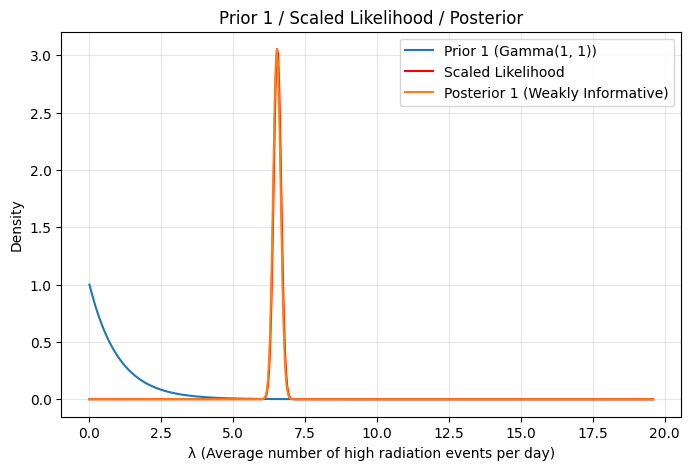

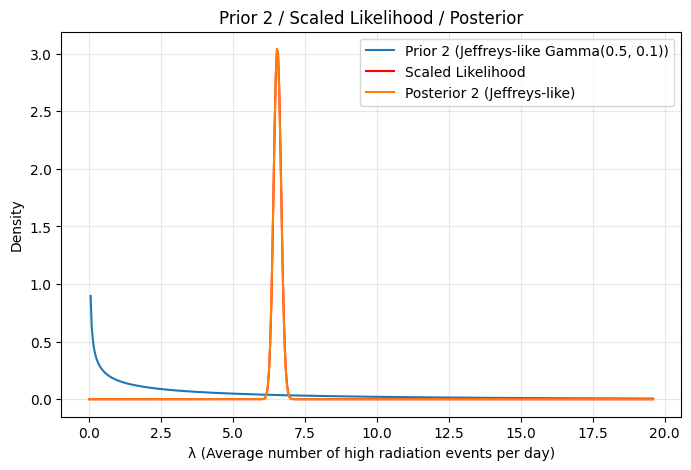

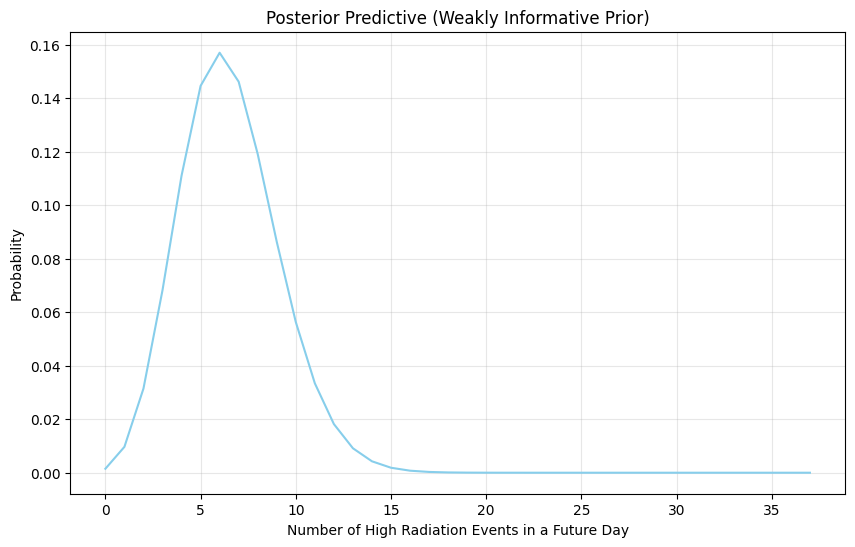

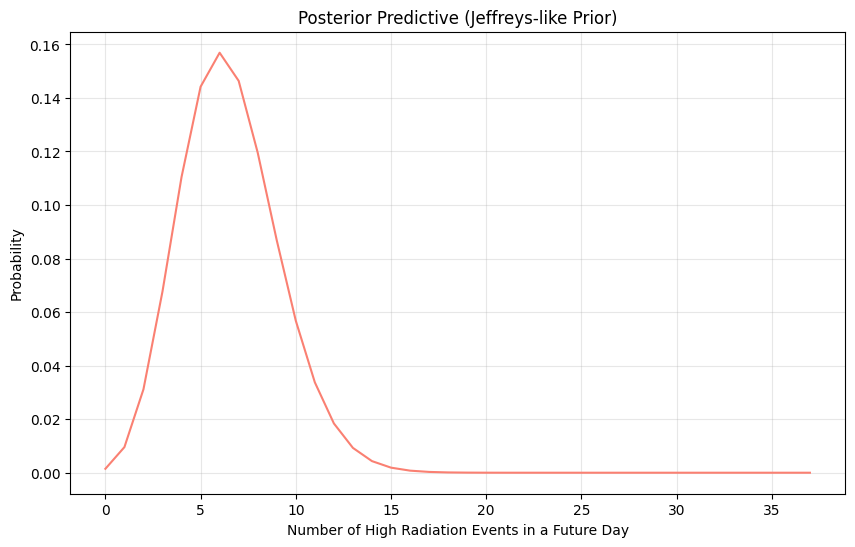

Weakly Informative Prior Posterior Mean λ̂ (per day) = 6.518
Weakly Informative Prior 95% Credible Interval: (6.265, 6.777)

Jeffreys-like Prior Posterior Mean λ̂ (per day) = 6.532
Jeffreys-like Prior 95% Credible Interval: (6.278, 6.791)



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, poisson, nbinom, gaussian_kde

c = daily_counts_array
D = len(c)
sum_c = np.sum(c)

print(f"Total high-radiation events (> 400 W/m²): {sum_c}, Number of days: {D}")

alpha0_1, beta0_1 = 1, 1
alpha0_2, beta0_2 = 0.5, 0.1

alpha_n1 = alpha0_1 + sum_c
beta_n1 = beta0_1 + D

alpha_n2 = alpha0_2 + sum_c
beta_n2 = beta0_2 + D

posterior_mean_weak = alpha_n1 / beta_n1
posterior_mean_jeffreys = alpha_n2 / beta_n2
max_lambda = max(posterior_mean_weak, posterior_mean_jeffreys) * 3
lambda_vals = np.linspace(0, max_lambda, 500)

log_likelihood = sum_c * np.log(lambda_vals + 1e-9) - D * lambda_vals
likelihood = np.exp(log_likelihood - np.max(log_likelihood))

prior1_pdf = gamma.pdf(lambda_vals, a=alpha0_1, scale=1/beta0_1)
posterior1_pdf = gamma.pdf(lambda_vals, a=alpha_n1, scale=1/beta_n1)

max_posterior_pdf1 = posterior1_pdf.max()
likelihood_scaled1 = likelihood * (max_posterior_pdf1 / likelihood.max())


plt.figure(figsize=(8,5))
plt.plot(lambda_vals, prior1_pdf, label=f'Prior 1 (Gamma({alpha0_1}, {beta0_1}))')
plt.plot(lambda_vals, likelihood_scaled1, label='Scaled Likelihood', color='red')
plt.plot(lambda_vals, posterior1_pdf, label='Posterior 1 (Weakly Informative)')
plt.title("Prior 1 / Scaled Likelihood / Posterior")
plt.xlabel("λ (Average number of high radiation events per day)")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

prior2_pdf = gamma.pdf(lambda_vals, a=alpha0_2, scale=1/beta0_2)
posterior2_pdf = gamma.pdf(lambda_vals, a=alpha_n2, scale=1/beta_n2)

max_posterior_pdf2 = posterior2_pdf.max()
likelihood_scaled2 = likelihood * (max_posterior_pdf2 / likelihood.max())

plt.figure(figsize=(8,5))
plt.plot(lambda_vals, prior2_pdf, label=f'Prior 2 (Jeffreys-like Gamma({alpha0_2}, {beta0_2}))')
plt.plot(lambda_vals, likelihood_scaled2, label='Scaled Likelihood', color='red')
plt.plot(lambda_vals, posterior2_pdf, label='Posterior 2 (Jeffreys-like)')
plt.title("Prior 2 / Scaled Likelihood / Posterior")
plt.xlabel("λ (Average number of high radiation events per day)")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

predicted_mean_weak = posterior_mean_weak
predicted_mean_jeffreys = posterior_mean_jeffreys
max_predicted_count = int(max(predicted_mean_weak, predicted_mean_jeffreys) * 5) + 5
counts = np.arange(0, max_predicted_count + 1)


r1, p1 = alpha_n1, beta_n1 / (beta_n1 + 1)
pred1_pmf = nbinom.pmf(counts, n=r1, p=p1)

plt.figure(figsize=(10,6))
plt.plot(counts, pred1_pmf, color='skyblue', linestyle='-')
plt.title("Posterior Predictive (Weakly Informative Prior)")
plt.xlabel("Number of High Radiation Events in a Future Day")
plt.ylabel("Probability")
plt.grid(alpha=0.3)
plt.show()

r2, p2 = alpha_n2, beta_n2 / (beta_n2 + 1)
pred2_pmf = nbinom.pmf(counts, n=r2, p=p2)

plt.figure(figsize=(10,6))
plt.plot(counts, pred2_pmf, color='salmon', linestyle='-')
plt.title("Posterior Predictive (Jeffreys-like Prior)")
plt.xlabel("Number of High Radiation Events in a Future Day")
plt.ylabel("Probability")
plt.grid(alpha=0.3)
plt.show()


def summarize_posterior(alpha_n, beta_n, name):
    mean = alpha_n / beta_n
    ci_lower = gamma.ppf(0.025, a=alpha_n, scale=1/beta_n)
    ci_upper = gamma.ppf(0.975, a=alpha_n, scale=1/beta_n)
    print(f"{name} Posterior Mean λ̂ (per day) = {mean:.3f}")
    print(f"{name} 95% Credible Interval: ({ci_lower:.3f}, {ci_upper:.3f})\n")

summarize_posterior(alpha_n1, beta_n1, "Weakly Informative Prior")
summarize_posterior(alpha_n2, beta_n2, "Jeffreys-like Prior")



**Summary:** Daily high-radiation event counts were modeled using a Poisson likelihood with a Gamma prior on the rate parameter.

**Outputs:** Calculated point estimates and central posterior intervals for the parameter and plotted distributions of priors, Scaled likelihood, posterior for different priors. The Jeffreys-like prior gives wider uncertainty; the weak prior yields more concentrated estimates.


# GAMMA-GAMMA WITH SHAPE PARAMETER FIXED KNOWN

Number of continuous radiation data points (> 300 W/m²): 2910
Sum of continuous radiation data: 1824384.000
Fixed shape parameter (α): 3


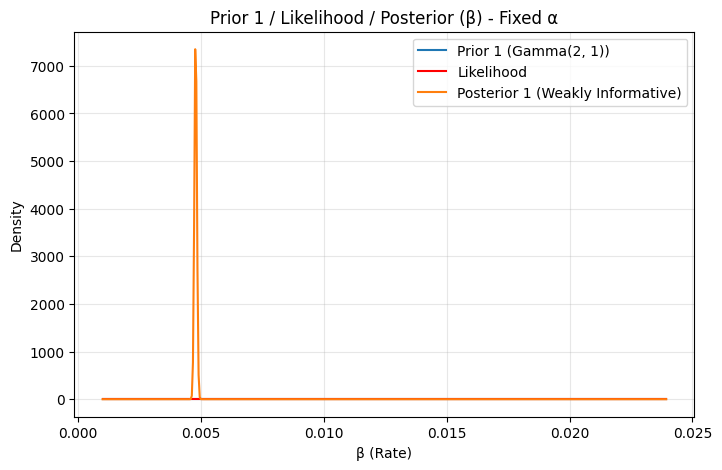

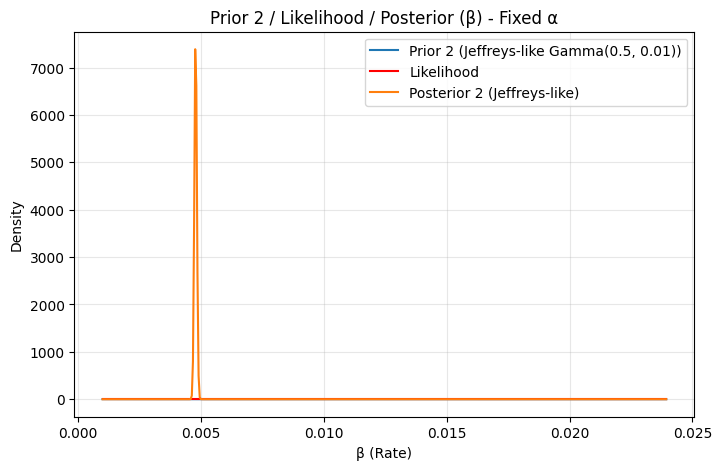

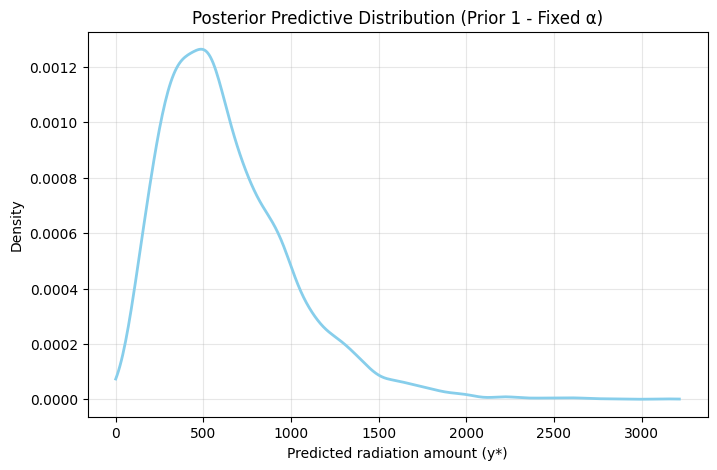

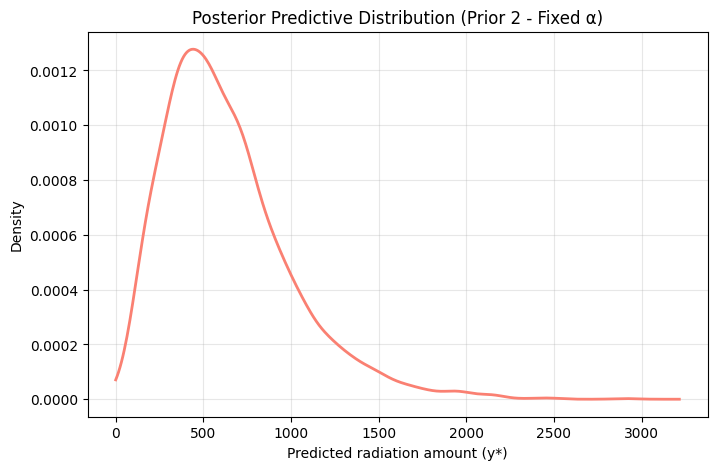

Prior 1 (Weakly Informative) Posterior Mean β̂ = 0.00479
Prior 1 (Weakly Informative) 95% Credible Interval: (0.00469, 0.00489)

Prior 2 (Jeffreys-like) Posterior Mean β̂ = 0.00479
Prior 2 (Jeffreys-like) 95% Credible Interval: (0.00469, 0.00489)



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, gaussian_kde

y = df_positive['global_tilted_irradiance'].dropna().values
y = y[y > 300]

n = len(y)
sum_y = np.sum(y)

alpha = 3

print(f"Number of continuous radiation data points (> 300 W/m²): {n}")
print(f"Sum of continuous radiation data: {sum_y:.3f}")
print(f"Fixed shape parameter (α): {alpha}")

alpha0_1_beta, beta0_1_beta = 2, 1

alpha0_2_beta, beta0_2_beta = 0.5, 0.01

alpha_n1_beta = alpha0_1_beta + n * alpha
beta_n1_beta = beta0_1_beta + sum_y

alpha_n2_beta = alpha0_2_beta + n * alpha
beta_n2_beta = beta0_2_beta + sum_y

beta_vals = np.linspace(0.001, (alpha_n1_beta / beta_n1_beta) * 5, 500)

log_likelihood_beta = (n * alpha) * np.log(beta_vals + 1e-9) - beta_vals * sum_y
likelihood_beta = np.exp(log_likelihood_beta)

prior1_beta_pdf = gamma.pdf(beta_vals, a=alpha0_1_beta, scale=1/beta0_1_beta)
posterior1_beta_pdf = gamma.pdf(beta_vals, a=alpha_n1_beta, scale=1/beta_n1_beta)

plt.figure(figsize=(8,5))
plt.plot(beta_vals, prior1_beta_pdf, label=f'Prior 1 (Gamma({alpha0_1_beta}, {beta0_1_beta}))')
plt.plot(beta_vals, likelihood_beta, label='Likelihood', color='red')
plt.plot(beta_vals, posterior1_beta_pdf, label='Posterior 1 (Weakly Informative)')
plt.title("Prior 1 / Likelihood / Posterior (β) - Fixed α")
plt.xlabel("β (Rate)")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

prior2_beta_pdf = gamma.pdf(beta_vals, a=alpha0_2_beta, scale=1/beta0_2_beta)
posterior2_beta_pdf = gamma.pdf(beta_vals, a=alpha_n2_beta, scale=1/beta_n2_beta)

plt.figure(figsize=(8,5))
plt.plot(beta_vals, prior2_beta_pdf, label=f'Prior 2 (Jeffreys-like Gamma({alpha0_2_beta}, {beta0_2_beta}))')
plt.plot(beta_vals, likelihood_beta, label='Likelihood', color='red')
plt.plot(beta_vals, posterior2_beta_pdf, label='Posterior 2 (Jeffreys-like)')
plt.title("Prior 2 / Likelihood / Posterior (β) - Fixed α")
plt.xlabel("β (Rate)")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

n_sim = 5000
beta_post1_samples = gamma.rvs(a=alpha_n1_beta, scale=1/beta_n1_beta, size=n_sim)

y_pred1_samples = gamma.rvs(a=alpha, scale=1/beta_post1_samples)

beta_post2_samples = gamma.rvs(a=alpha_n2_beta, scale=1/beta_n2_beta, size=n_sim)

y_pred2_samples = gamma.rvs(a=alpha, scale=1/beta_post2_samples)

kde1 = gaussian_kde(y_pred1_samples)
kde2 = gaussian_kde(y_pred2_samples)
y_grid = np.linspace(0, np.max(y_pred2_samples)*1.1, 400)

plt.figure(figsize=(8,5))
plt.plot(y_grid, kde1(y_grid), color='skyblue', lw=2)
plt.title("Posterior Predictive Distribution (Prior 1 - Fixed α)")
plt.xlabel("Predicted radiation amount (y*)")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(y_grid, kde2(y_grid), color='salmon', lw=2)
plt.title("Posterior Predictive Distribution (Prior 2 - Fixed α)")
plt.xlabel("Predicted radiation amount (y*)")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.show()

def summarize_posterior_beta(alpha_n, beta_n, name):
    mean = alpha_n / beta_n
    ci_lower = gamma.ppf(0.025, a=alpha_n, scale=1/beta_n)
    ci_upper = gamma.ppf(0.975, a=alpha_n, scale=1/beta_n)
    print(f"{name} Posterior Mean β̂ = {mean:.5f}")
    print(f"{name} 95% Credible Interval: ({ci_lower:.5f}, {ci_upper:.5f})\n")

summarize_posterior_beta(alpha_n1_beta, beta_n1_beta, "Prior 1 (Weakly Informative)")
summarize_posterior_beta(alpha_n2_beta, beta_n2_beta, "Prior 2 (Jeffreys-like)")

**Summary:** This cell performs Bayesian inference for the rate parameter ($\beta$) of a Gamma distribution, assuming the shape parameter ($\alpha$) is known. It uses Gamma priors and the Gamma likelihood, resulting in Gamma posterior distributions for $\beta$. It also analyzes the resulting Gamma posterior predictive distributions. The analysis is applied to a subset of the global tilted irradiance data where values are greater than 300 W/m².

**Outputs:** The cell outputs plots showing the prior and posterior distributions for $\beta$ under two different Gamma priors. It also plots the posterior predictive distributions for future radiation amounts. Printed outputs include the number of data points, the sum of the data, the fixed shape parameter, and the posterior mean and 95% credible intervals for $\beta$.

**Insights:** This analysis demonstrates how different prior beliefs about the rate parameter ($\beta$) influence its posterior distribution. The plots and intervals reveal the updated estimate and uncertainty for the rate of the Gamma distribution based on the observed high radiation data. The posterior predictive plots show the expected distribution of future high radiation values, incorporating the uncertainty in the estimated rate. Comparing results from different priors highlights the impact of initial assumptions on both the rate estimate and the prediction of future radiation amounts.